#step 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
from pathlib import Path

print("="*70)
print("SITTING DATA EXPLORATION")
print("="*70)

# Paths - ADJUST THESE
BASE_PATH = '/content/drive/MyDrive/CS5103_IITH_PMA_project/Darsh-running'
ZIP_PATH = f'{BASE_PATH}/running.zip'  # Your 70MB zip file

# Step 1: Extract zip if needed
print("\n1. Checking data files...")
if ZIP_PATH.endswith('.zip'):
    print(f"   Found zip file: {os.path.basename(ZIP_PATH)}")
    print(f"   Size: {os.path.getsize(ZIP_PATH) / 1024 / 1024:.2f} MB")

    # Extract
    extract_dir = f'{BASE_PATH}/extracted'
    os.makedirs(extract_dir, exist_ok=True)

    print(f"   Extracting to: {extract_dir}")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    print(f"   \u2713 Extracted!")

    # List files
    print(f"\n   Files in archive:")
    for root, dirs, files in os.walk(extract_dir):
        for file in files:
            filepath = os.path.join(root, file)
            size_mb = os.path.getsize(filepath) / 1024 / 1024
            print(f"      - {file} ({size_mb:.2f} MB)")

# Step 2: Load all CSV files
print("\n2. Loading CSV files...")

csv_files = []
for root, dirs, files in os.walk(extract_dir if 'extract_dir' in locals() else BASE_PATH):
    for file in files:
        if file.endswith('.csv'):
            csv_files.append(os.path.join(root, file))

print(f"   Found {len(csv_files)} CSV files")

if len(csv_files) == 0:
    print("   \u274c No CSV files found! Please check the path.")
    exit()

# Analyze each CSV
print("\n3. Analyzing each CSV file:")
print("="*70)

all_data = {}

for csv_file in csv_files:
    filename = os.path.basename(csv_file)
    print(f"\n\U0001f4c6 {filename}")

    try:
        # Use low_memory=False for better type inference with mixed types
        df = pd.read_csv(csv_file, low_memory=False)

        # Attempt to convert 'time' and 'seconds_elapsed' to numeric if they are not already
        for col_name in ['time', 'seconds_elapsed']:
            if col_name in df.columns:
                # Check if the column contains non-numeric strings that can be converted
                if pd.api.types.is_object_dtype(df[col_name]):
                    # Try to convert to numeric, coercing errors to NaN
                    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
                    # Drop rows where conversion resulted in NaN for these critical columns
                    df.dropna(subset=[col_name], inplace=True)

        # Specifically handle Orientation.csv columns if they are strings
        if filename == 'Orientation.csv':
            orientation_cols = ['qz', 'qy', 'qx', 'qw', 'roll', 'pitch', 'yaw']
            for col_name in orientation_cols:
                if col_name in df.columns and pd.api.types.is_object_dtype(df[col_name]):
                    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
                    df.dropna(subset=[col_name], inplace=True)

        all_data[filename] = df

        print(f"   Shape: {df.shape}")
        print(f"   Columns: {list(df.columns)}")
        print(f"   Duration: {len(df)} samples")

        # Check for time column
        time_cols = [col for col in df.columns if 'time' in col.lower()]
        if time_cols:
            print(f"   Time column: {time_cols[0]}")
            # Ensure time column is numeric before calculating range
            if pd.api.types.is_numeric_dtype(df[time_cols[0]]) and len(df) > 1:
                # Assuming nanoseconds timestamp if value is large
                if df[time_cols[0]].max() > 1e12:
                    duration_sec = (df[time_cols[0]].max() - df[time_cols[0]].min()) / 1e9
                else:
                    duration_sec = (df[time_cols[0]].max() - df[time_cols[0]].min())
                print(f"   Time range: {duration_sec:.2f} seconds ({duration_sec/60:.2f} minutes)")
            elif len(df) <=1: # Handle single row cases more gracefully
                 print(f"   Time range: N/A (single sample or non-numeric time)")
            else:
                 print(f"   Time range: N/A (non-numeric time column or too few samples)")
        else:
            print(f"   No explicit time column found.")

        # Data types
        print(f"   Data types: {df.dtypes.value_counts().to_dict()}")

        # Missing values
        missing = df.isnull().sum().sum()
        if missing > 0:
            print(f"   \u26a0\ufe0f  Missing values: {missing}")
        else:
            print(f"   \u2713 No missing values")

        # Basic stats
        print(f"   Sample values (first row):")
        if not df.empty:
            print(f"      {df.iloc[0].to_dict()}")
        else:
            print("      (Empty DataFrame)")

    except Exception as e:
        print(f"   \u274c Error loading: {e}")

# Step 4: Determine sensor structure
print("\n" + "="*70)
print("4. SENSOR STRUCTURE ANALYSIS")
print("="*70)

# Check if multiple files (one per sensor) or single merged file
if len(csv_files) == 1:
    print("\n\u2713 Single merged file detected")
    df = all_data[csv_files[0]]

    # Identify sensor columns
    sensor_cols = [col for col in df.columns if col.lower() != 'time']
    print(f"\n   Total features: {len(sensor_cols)}")
    print(f"   Feature names: {sensor_cols}")

    # Group by sensor type
    sensor_groups = {
        'accelerometer': [col for col in sensor_cols if 'acc' in col.lower()],
        'gyroscope': [col for col in sensor_cols if 'gyro' in col.lower()],
        'magnetometer': [col for col in sensor_cols if 'mag' in col.lower()],
        'orientation': [col for col in sensor_cols if 'orient' in col.lower() or 'quat' in col.lower()],
        'gravity': [col for col in sensor_cols if 'grav' in col.lower()],
        'linear_acc': [col for col in sensor_cols if 'linear' in col.lower()],
        'rotation': [col for col in sensor_cols if 'rot' in col.lower()],
    }

    print(f"\n   Sensors detected:")
    total_features = 0
    for sensor_type, cols in sensor_groups.items():
        if cols:
            print(f"      {sensor_type}: {len(cols)} features - {cols}")
            total_features += len(cols)

    print(f"\n   Total sensor features: {total_features}")

elif len(csv_files) > 1:
    print(f"\n\u2713 Multiple sensor files detected ({len(csv_files)} files)")

    for filename, df in all_data.items():
        # Try to infer sensor type from filename, fallback to filename itself
        sensor_type_parts = filename.split('.')[0].split('_')
        if len(sensor_type_parts) > 1 and sensor_type_parts[-1].lower() not in ['csv', 'metadata', 'uncalibrated']:
            sensor_type = sensor_type_parts[-1]
        else:
            sensor_type = filename.split('.')[0]

        print(f"\n   {sensor_type}:")
        print(f"      Rows: {len(df)}")
        print(f"      Columns: {list(df.columns)}")

# Step 5: Statistical analysis
print("\n" + "="*70)
print("5. STATISTICAL ANALYSIS")
print("="*70)

# Find a suitable main_df for analysis (e.g., first sensor data with > 1 row and 'time' column)
main_df_key = None
for filename, df_val in all_data.items():
    # Check if df_val is not empty before accessing columns
    if not df_val.empty and len(df_val) > 1 and ('time' in df_val.columns or 'seconds_elapsed' in df_val.columns) and 'metadata' not in filename.lower():
        # Ensure the identified time column is numeric
        potential_time_col = 'time' if 'time' in df_val.columns else 'seconds_elapsed'
        if pd.api.types.is_numeric_dtype(df_val[potential_time_col]):
            main_df_key = filename
            break

if main_df_key:
    main_df = all_data[main_df_key]
    print(f"\nUsing '{main_df_key}' as main dataframe for statistical analysis and visualizations.")
else:
    # Fallback if no suitable sensor data found, but warn user
    print("\nWarning: No suitable sensor dataframe (multi-row, with numeric 'time' or 'seconds_elapsed' column) found for main analysis.")
    if all_data:
        # Take the first available dataframe if no ideal one is found
        main_df = next(iter(all_data.values()))
        print("         Proceeding with the first available dataframe, but results may be limited or incorrect.")
    else:
        print("         No dataframes available for analysis. Exiting.")
        exit() # Exit if no dataframes at all

# Get numeric columns only
numeric_cols = main_df.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if 'time' not in col.lower() and 'elapsed' not in col.lower()]

if len(numeric_cols) == 0:
    print("\nNo numeric columns found for statistical analysis in the selected main dataframe.")
    stats_df = pd.DataFrame()
elif main_df.empty:
    print("\nMain dataframe is empty, skipping statistical analysis.")
    stats_df = pd.DataFrame()
else:
    print(f"\nAnalyzing {len(numeric_cols)} numeric features...")

    stats_summary = []
    for col in numeric_cols:
        data = main_df[col].dropna()
        if not data.empty:
            stats = {
                'feature': col,
                'mean': data.mean(),
                'std': data.std(),
                'min': data.min(),
                'max': data.max(),
                'range': data.max() - data.min(),
                'variance': data.var()
            }
            stats_summary.append(stats)

    stats_df = pd.DataFrame(stats_summary)

    print("\nFeature Statistics:")
    print(stats_df.to_string(index=False))

    # Save stats
    stats_df.to_csv(f'{BASE_PATH}/sitting_data_statistics.csv', index=False)
    print(f"\n\u2713 Saved: sitting_data_statistics.csv")

# Step 6: Visualizations
print("\n" + "="*70)
print("6. GENERATING VISUALIZATIONS")
print("="*70)

if not numeric_cols:
    print("No numeric columns to visualize. Skipping visualization steps.")
elif main_df.empty or len(main_df) <= 1:
    print("Main dataframe is empty or has too few samples for meaningful visualizations. Skipping visualization steps.")
else:
    # Plot 1: Time series of first few features
    print("\n   Creating time series plots...")

    n_features_to_plot = min(6, len(numeric_cols))
    if n_features_to_plot > 0:
        fig, axes = plt.subplots(n_features_to_plot, 1, figsize=(15, 3*n_features_to_plot))
        if n_features_to_plot == 1:
            axes = [axes]

        # Robustly find a time column for plotting
        plot_time_col_name = None
        for potential_col in ['seconds_elapsed', 'time']:
            if potential_col in main_df.columns and pd.api.types.is_numeric_dtype(main_df[potential_col]):
                plot_time_col_name = potential_col
                break

        if plot_time_col_name and len(main_df[plot_time_col_name].values) > 1:
            # Convert epoch time to seconds if it's a large numeric value (nanoseconds) or use seconds_elapsed directly
            if main_df[plot_time_col_name].max() > 1e12:
                x_data = (main_df[plot_time_col_name].values - main_df[plot_time_col_name].min()) / 1e9
                x_label = 'Time (seconds)'
            else:
                x_data = main_df[plot_time_col_name].values
                x_label = 'Time (seconds)' if plot_time_col_name == 'seconds_elapsed' else 'Time (raw units)'
        else:
            x_data = np.arange(len(main_df))
            x_label = 'Sample Index'

        for idx, col in enumerate(numeric_cols[:n_features_to_plot]):
            axes[idx].plot(x_data, main_df[col].values, linewidth=0.5, alpha=0.7)
            axes[idx].set_ylabel(col, fontweight='bold')
            axes[idx].grid(True, alpha=0.3)
            axes[idx].set_title(f'{col} - Mean: {main_df[col].mean():.3f}, Std: {main_df[col].std():.3f}')

        axes[-1].set_xlabel(x_label)
        plt.suptitle('Running Data: Time Series', fontsize=16, fontweight='bold', y=1.0)
        plt.tight_layout()
        plt.savefig(f'{BASE_PATH}/sitting_timeseries.png', dpi=150, bbox_inches='tight')
        print(f"   \u2713 Saved: sitting_timeseries.png")
        plt.close()
    else:
        print("   Not enough features for time series plots.")

    # Plot 2: Distribution histograms
    print("\n   Creating distribution plots...")
    if n_features_to_plot > 0:
        fig, axes = plt.subplots(n_features_to_plot, 1, figsize=(12, 3*n_features_to_plot))
        if n_features_to_plot == 1:
            axes = [axes]

        for idx, col in enumerate(numeric_cols[:n_features_to_plot]):
            axes[idx].hist(main_df[col].dropna(), bins=50, alpha=0.7, color='steelblue', edgecolor='black')
            axes[idx].set_ylabel('Frequency', fontweight='bold')
            axes[idx].set_xlabel(col, fontweight='bold')
            axes[idx].grid(True, alpha=0.3, axis='y')
            axes[idx].axvline(main_df[col].mean(), color='red', linestyle='--',
                              linewidth=2, label=f'Mean: {main_df[col].mean():.3f}')
            axes[idx].legend()

        plt.suptitle('Sitting Data: Distributions', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{BASE_PATH}/Sitting_distributions.png', dpi=150, bbox_inches='tight')
        print(f"   \u2713 Saved: Sitting_distributions.png")
        plt.close()
    else:
        print("   Not enough features for distribution plots.")

    # Plot 3: Correlation heatmap
    print("\n   Creating correlation heatmap...")

    if len(numeric_cols) > 1 and len(numeric_cols) <= 20:  # Only if not too many features and more than 1 feature
        corr_matrix = main_df[numeric_cols].corr()

        plt.figure(figsize=(12, 10))
        sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
                    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
        plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.savefig(f'{BASE_PATH}/Sitting_correlation.png', dpi=150, bbox_inches='tight')
        print(f"   \u2713 Saved: Sitting_correlation.png")
        plt.close()
    elif len(numeric_cols) <= 1:
        print("   Not enough numeric features for correlation heatmap.")
    else:
        print("   Too many features for correlation heatmap (max 20 recommended).")

# Step 7: Data quality checks
print("\n" + "="*70)
print("7. DATA QUALITY CHECKS")
print("="*70)

if main_df_key and len(main_df) > 1:
    # Robustly find a time column for calculations
    calc_time_col_name = None
    for potential_col in ['seconds_elapsed', 'time']:
        if potential_col in main_df.columns and pd.api.types.is_numeric_dtype(main_df[potential_col]):
            calc_time_col_name = potential_col
            break

    if calc_time_col_name and len(main_df) > 1:
        # Convert epoch time to seconds if it's a large numeric value (nanoseconds)
        if main_df[calc_time_col_name].max() > 1e12:
            time_values_sec = (main_df[calc_time_col_name].values - main_df[calc_time_col_name].min()) / 1e9
        else:
            time_values_sec = main_df[calc_time_col_name].values

        time_diffs = np.diff(time_values_sec)
        if len(time_diffs) > 0:
            avg_interval = np.mean(time_diffs)
            sampling_rate = 1.0 / avg_interval if avg_interval > 0 else None

            print(f"\n   Time interval analysis:")
            print(f"      Mean interval: {avg_interval*1000:.2f} ms")
            if sampling_rate is not None:
                print(f"      Estimated sampling rate: {sampling_rate:.2f} Hz")
            else:
                print(f"      Estimated sampling rate: N/A (average interval is 0 or NaN)")
            print(f"      Min interval: {time_diffs.min()*1000:.2f} ms")
            print(f"      Max interval: {time_diffs.max()*1000:.2f} ms")
            print(f"      Std interval: {time_diffs.std()*1000:.2f} ms")

            # Check consistency
            if avg_interval > 0 and time_diffs.std() / avg_interval < 0.1:
                print(f"      \u2713 Consistent sampling rate")
            elif avg_interval > 0:
                print(f"      \u26a0\ufe0f  Variable sampling rate")
            else:
                 print(f"      Cannot determine sampling rate consistency (average interval is 0 or NaN).")
        else:
            print("\n   Time interval analysis: Not enough data points to calculate intervals.")
    else:
        print("\n   Time column not found or dataframe has too few samples for time interval analysis.")
else:
    print("\n   Skipping data quality checks: Main dataframe not suitable for time series analysis.")

# Check for outliers (simple 3-sigma rule)
if len(numeric_cols) > 0 and not main_df.empty:
    print(f"\n   Outlier detection (3-sigma rule):")
    for col in numeric_cols[:6]:  # First 6 features
        data = main_df[col].dropna()
        if not data.empty and data.std() > 0:
            mean = data.mean()
            std = data.std()
            outliers = np.sum((data < mean - 3*std) | (data > mean + 3*std))
            outlier_pct = outliers / len(data) * 100

            status = "\u2713" if outlier_pct < 1 else "\u26a0\ufe0f"
            print(f"      {col}: {outliers} outliers ({outlier_pct:.2f}%) {status}")
        else:
            print(f"      {col}: Not enough data or zero standard deviation to check for outliers.")
else:
    print("\n   No numeric columns to check for outliers.")

# Step 8: Summary report
print("\n" + "="*70)
print("8. SUMMARY REPORT")
print("="*70)

summary = {
    'total_files': len(csv_files),
    'total_samples': len(main_df) if not main_df.empty else 0,
    'total_features': len(numeric_cols),
    'duration_seconds': None,
    'sampling_rate_hz': None,
    'missing_values': int(main_df.isnull().sum().sum()) if not main_df.empty else 0,
    'file_size_mb': float(os.path.getsize(ZIP_PATH) / 1024 / 1024),
    'feature_list': list(numeric_cols),
}

if main_df_key and not main_df.empty and len(main_df) > 1:
    # Robustly find a time column for calculations
    calc_time_col_name = None
    for potential_col in ['seconds_elapsed', 'time']:
        if potential_col in main_df.columns and pd.api.types.is_numeric_dtype(main_df[potential_col]):
            calc_time_col_name = potential_col
            break

    if calc_time_col_name and len(main_df) > 1:
        if main_df[calc_time_col_name].max() > 1e12:
             duration_sec = (main_df[calc_time_col_name].max() - main_df[calc_time_col_name].min()) / 1e9
        else:
             duration_sec = main_df[calc_time_col_name].max() - main_df[calc_time_col_name].min()

        summary['duration_seconds'] = float(duration_sec)

        # Convert time values to seconds for sampling rate calculation
        if main_df[calc_time_col_name].max() > 1e12:
            time_values_sec = (main_df[calc_time_col_name].values - main_df[calc_time_col_name].min()) / 1e9
        else:
            time_values_sec = main_df[calc_time_col_name].values

        time_diffs = np.diff(time_values_sec)
        if len(time_diffs) > 0 and np.mean(time_diffs) > 0:
            summary['sampling_rate_hz'] = float(1.0 / np.mean(time_diffs))

print(f"\n\U0001f4c8 Running Data Summary:")
print(f"   Total samples: {summary['total_samples']:,}")
print(f"   Total features: {summary['total_features']}")
if summary['duration_seconds'] is not None:
    print(f"   Duration: {summary['duration_seconds']:.1f} seconds ({summary['duration_seconds']/60:.1f} minutes)")
if summary['sampling_rate_hz'] is not None:
    print(f"   Sampling rate: {summary['sampling_rate_hz']:.1f} Hz")
print(f"   File size: {summary['file_size_mb']:.2f} MB")
print(f"   Missing values: {summary['missing_values']}")

# Save summary
import json
with open(f'{BASE_PATH}/Sitting_data_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f"\n\u2713 Saved: Sitting_data_summary.json")

# Step 9: Comparison with cycling data
print("\n" + "="*70)
print("9. COMPARISON WITH CYCLING DATA")
print("="*70)

running_duration_str = f'{summary["duration_seconds"]/60:.1f} minutes' if summary['duration_seconds'] is not None else 'N/A'
running_sampling_rate_str = f'{summary["sampling_rate_hz"]:.0f} Hz' if summary['sampling_rate_hz'] is not None else 'N/A'

print(f"\n{'Metric':<30} {'Cycling':<20} {'Running':<20}")
print("-"*70)

print(f"{'Dataset size':<30} {'~240 seconds':<20} {running_duration_str:<20}")
print(f"{'Total sequences (50% overlap)':<30} {'479':<20} {'???':<20}") # Cannot calculate without sequence parameters
print(f"{'Total sequences (no overlap)':<30} {'192':<20} {'???':<20}") # Cannot calculate without sequence parameters
print(f"{'Sampling rate':<30} {'100 Hz':<20} {running_sampling_rate_str:<20}")
print(f"{'Features':<30} {'19':<20} {summary['total_features']:<20}")

if summary['duration_seconds'] is not None and summary['duration_seconds'] > 240:
    improvement_factor = summary['duration_seconds'] / 240
    print(f"\n\u2705 Running data is {improvement_factor:.1f}x larger!")
    print(f"   This should give MUCH better GAN training!")
elif summary['duration_seconds'] is not None:
    print(f"\n\u26a0\ufe0f Running data is {summary['duration_seconds']:.1f} seconds, which might be less than target cycling data (240s).")
else:
    print("\nCannot compare dataset size without duration information.")

print("\n" + "="*70)
print("\u2705 EXPLORATION COMPLETE!")
print("="*70)

print(f"\nGenerated files:")
print(f"   - Sitting_data_statistics.csv")
print(f"   - Sitting_data_summary.json")
if n_features_to_plot > 0 and len(main_df) > 1:
    print(f"   - Sitting_timeseries.png")
    print(f"   - Sitting_distributions.png")
if len(numeric_cols) > 1 and len(numeric_cols) <= 20:
    print(f"   - Sitting_correlation.png")

print(f"\n\U0001f3af NEXT STEPS:")
print(f"   1. Review the visualizations")
print(f"   2. Check data quality (outliers, missing values)")
print(f"   3. Decide on features to use")
print(f"   4. Proceed to data preprocessing")

print(f"\n\U0001f4a1 KEY QUESTIONS TO ANSWER:")
print(f"   - Is sampling rate consistent? (check running_timeseries.png)")
print(f"   - Are there outliers? (check distributions)")
print(f"   - How many sequences can we create?")
print(f"   - Which features to include? (all? or subset?)")

SITTING DATA EXPLORATION

1. Checking data files...
   Found zip file: Sitting.zip
   Size: 63.49 MB
   Extracting to: /content/drive/MyDrive/CS5103_IITH_PMA_project/Darsh-sitting/extracted
   ✓ Extracted!

   Files in archive:
      - Orientation.csv (42.20 MB)
      - TotalAcceleration.csv (39.05 MB)
      - Network.csv (0.29 MB)
      - Magnetometer.csv (36.77 MB)
      - MagnetometerUncalibrated.csv (36.43 MB)
      - Metadata.csv (0.00 MB)
      - GyroscopeUncalibrated.csv (40.04 MB)
      - Light.csv (0.12 MB)
      - Location.csv (0.00 MB)
      - Accelerometer.csv (39.77 MB)
      - AccelerometerUncalibrated.csv (0.00 MB)
      - Annotation.csv (0.00 MB)
      - Gyroscope.csv (35.54 MB)

2. Loading CSV files...
   Found 13 CSV files

3. Analyzing each CSV file:

📆 Orientation.csv
   Shape: (413216, 9)
   Columns: ['time', 'seconds_elapsed', 'qz', 'qy', 'qx', 'qw', 'roll', 'pitch', 'yaw']
   Duration: 413216 samples
   Time column: time
   Time range: 0.00 seconds (0.00 minutes)

#step 2

In [ ]:

"""
STEP 2: MERGE MOTION SENSORS - RUNNING DATA
Combine accelerometer, gyroscope, magnetometer, gravity, orientation
Same structure as cycling data
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("="*70)
print("MERGING WALKING MOTION SENSORS")
print("="*70)

BASE_PATH = '/content/drive/MyDrive/CS5103_IITH_PMA_project/Darsh-sitting/extracted'
EXTRACT_PATH = f'{BASE_PATH}'

# Step 1: Load motion sensor files
print("\n1. Loading motion sensor files...")

sensors = {
    'Accelerometer': 'Accelerometer.csv',
    'Gyroscope': 'Gyroscope.csv',
    'Magnetometer': 'Magnetometer.csv',
    'Gravity': 'Gravity.csv', # Gravity.csv was not found in the extracted files, so commenting it out
    'Orientation': 'Orientation.csv'
}

dfs = {}
for sensor_name, filename in sensors.items():
    filepath = os.path.join(EXTRACT_PATH, filename)
    print(f"   Loading {sensor_name}...")
    if os.path.exists(filepath):
        # Use low_memory=False for better type inference
        df = pd.read_csv(filepath, low_memory=False)

        # Ensure 'seconds_elapsed' is numeric
        if 'seconds_elapsed' in df.columns:
            df['seconds_elapsed'] = pd.to_numeric(df['seconds_elapsed'], errors='coerce')
            df.dropna(subset=['seconds_elapsed'], inplace=True)

        # Explicitly convert Orientation.csv columns if they are still object type
        if sensor_name == 'Orientation':
            orientation_cols = ['qz', 'qy', 'qx', 'qw', 'roll', 'pitch', 'yaw']
            for col_name in orientation_cols:
                if col_name in df.columns and pd.api.types.is_object_dtype(df[col_name]):
                    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
                    df.dropna(subset=[col_name], inplace=True)

        print(f"      Shape: {df.shape}")
        print(f"      Columns: {list(df.columns)}")
        # Check if df is not empty and 'seconds_elapsed' is numeric before trying to find min/max
        if not df.empty and pd.api.types.is_numeric_dtype(df['seconds_elapsed']):
            print(f"      Time range: {df['seconds_elapsed'].min():.3f} - {df['seconds_elapsed'].max():.3f} seconds")
            dfs[sensor_name] = df
        else:
            print(f"      \u274c Could not determine time range for {filename} due to empty data or non-numeric 'seconds_elapsed'. Skipping this sensor.")
    else:
        print(f"      \u274c File not found: {filename}. Skipping this sensor.")

# Check if any dataframes were successfully loaded
if not dfs:
    print("\n\u274c No sensor dataframes were successfully loaded. Exiting.")
    exit()

# Step 2: Check sampling rates
print("\n2. Checking sampling rates...")

for sensor_name, df in dfs.items():
    time_diffs = np.diff(df['seconds_elapsed'].values)
    avg_interval = np.mean(time_diffs)
    sampling_rate = 1.0 / avg_interval if avg_interval > 0 else None

    print(f"   {sensor_name}:")
    print(f"      Samples: {len(df)}")
    print(f"      Avg interval: {avg_interval*1000:.2f} ms")
    print(f"      Sampling rate: {sampling_rate:.1f} Hz")
    print(f"      Consistency: {time_diffs.std() / avg_interval * 100:.1f}% variation")

# Step 3: Resample to common timebase (100 Hz, like cycling)
print("\n3. Resampling to 100 Hz common timebase...")

TARGET_HZ = 100
TARGET_INTERVAL = 1.0 / TARGET_HZ  # 0.01 seconds = 10 ms

# Find common time range
min_time = max([df['seconds_elapsed'].min() for df in dfs.values()])
max_time = min([df['seconds_elapsed'].max() for df in dfs.values()])

print(f"   Common time range: {min_time:.3f} - {max_time:.3f} seconds")
print(f"   Duration: {max_time - min_time:.1f} seconds ({(max_time - min_time)/60:.1f} minutes)")

# Create common timebase
common_time = np.arange(min_time, max_time, TARGET_INTERVAL)
print(f"   Common timebase samples: {len(common_time)} at {TARGET_HZ} Hz")

# Resample each sensor
print("\n4. Resampling each sensor to common timebase...")

resampled = {}

for sensor_name, df in dfs.items():
    print(f"   Resampling {sensor_name}...")

    # Get data columns (exclude time columns)
    data_cols = [col for col in df.columns if col not in ['time', 'seconds_elapsed']]

    # Interpolate each column
    resampled_data = {}
    for col in data_cols:
        resampled_data[col] = np.interp(
            common_time,
            df['seconds_elapsed'].values,
            df[col].values
        )

    resampled[sensor_name] = resampled_data
    print(f"      Features: {data_cols}")

# Step 5: Merge into single dataframe
print("\n5. Merging all sensors...")

merged_data = {'time_seconds': common_time}

# Add features with sensor prefix
for sensor_name, data in resampled.items():
    for col, values in data.items():
        feature_name = f"{col}"  # e.g., "z", "y", "x", "qz", etc.

        # Add sensor prefix to avoid conflicts
        if sensor_name == 'Accelerometer':
            prefix = 'acc_'
        elif sensor_name == 'Gyroscope':
            prefix = 'gyro_'
        elif sensor_name == 'Magnetometer':
            prefix = 'mag_'
        elif sensor_name == 'Gravity':
            prefix = 'grav_'
        elif sensor_name == 'Orientation':
            prefix = 'orient_'

        merged_data[prefix + col] = values

merged_df = pd.DataFrame(merged_data)

print(f"   \u2713 Merged dataframe shape: {merged_df.shape}")
print(f"   \u2713 Columns: {list(merged_df.columns)}")
print(f"   \u2713 Duration: {merged_df['time_seconds'].max() - merged_df['time_seconds'].min():.1f} seconds")

# Step 6: Data quality checks
print("\n6. Data quality checks...")

# Check for NaN
nan_count = merged_df.isnull().sum().sum()
if nan_count > 0:
    print(f"   \u26a0\ufe0f  Found {nan_count} NaN values")
    print(f"   Filling with interpolation...")
    merged_df = merged_df.interpolate(method='linear', axis=0)
else:
    print(f"   \u2713 No NaN values")

# Check ranges
print("\n   Feature ranges:")
feature_cols = [col for col in merged_df.columns if col != 'time_seconds']
for col in feature_cols:
    mean_val = merged_df[col].mean()
    std_val = merged_df[col].std()
    min_val = merged_df[col].min()
    max_val = merged_df[col].max()
    print(f"      {col:<20} \u03bc={mean_val:>8.3f}, \u03c3={std_val:>7.3f}, range=[{min_val:>8.3f}, {max_val:>8.3f}]")

# Step 7: Visualize merged data
print("\n7. Creating visualizations...")

# Plot first 6 motion sensors (acc, gyro)
fig, axes = plt.subplots(6, 1, figsize=(15, 12))

motion_features = ['acc_z', 'acc_y', 'acc_x', 'gyro_z', 'gyro_y', 'gyro_x']

for idx, feature in enumerate(motion_features):
    # Plot first 10 seconds only for clarity
    time_mask = merged_df['time_seconds'] <= (merged_df['time_seconds'].min() + 10)

    axes[idx].plot(
        merged_df.loc[time_mask, 'time_seconds'].values,
        merged_df.loc[time_mask, feature].values,
        linewidth=0.8, alpha=0.7
    )
    axes[idx].set_ylabel(feature, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_title(
        f'{feature} - Mean: {merged_df[feature].mean():.3f}, Std: {merged_df[feature].std():.3f}',
        fontsize=10
    )

axes[-1].set_xlabel('Time (seconds)', fontweight='bold')
plt.suptitle('Sitting Data: Motion Sensors (First 10 seconds)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_PATH}/merged_sensors_preview.png', dpi=150, bbox_inches='tight')
print(f"   \u2713 Saved: merged_sensors_preview.png")
plt.close()

# Step 8: Save merged data
print("\n8. Saving merged data...")

# Save as CSV
csv_path = f'{BASE_PATH}/merged_sensors_100hz.csv'
merged_df.to_csv(csv_path, index=False)
print(f"   \u2713 Saved: {csv_path}")
print(f"   Size: {os.path.getsize(csv_path) / 1024 / 1024:.2f} MB")

# Step 9: Compute statistics
print("\n" + "="*70)
print("COMPARISON: Cycling vs Running")
print("="*70)

running_duration = merged_df['time_seconds'].max() - merged_df['time_seconds'].min()
running_samples = len(merged_df)
running_features = len(feature_cols)

print(f"\n{'Metric':<30} {'Cycling':<20} {'Running':<20}")
print("-"*70)
print(f"{'Duration (seconds)':<30} {'240':<20} {f'{running_duration:.1f}':<20}")
print(f"{'Duration (minutes)':<30} {'4.0':<20} {f'{running_duration/60:.1f}':<20}")
print(f"{'Samples (100 Hz)':<30} {'24,000':<20} {f'{running_samples:,}':<20}")
print(f"{'Features':<30} {'19':<20} {f'{running_features}':<20}")
print(f"{'File size (MB)':<30} {'~2':<20} {f'{os.path.getsize(csv_path)/1024/1024:.1f}':<20}")

# Estimate sequences
seq_length = 100  # 1 second at 100 Hz
stride = 100  # No overlap

cycling_sequences_no_overlap = 192
running_sequences_no_overlap = (running_samples - seq_length) // stride

print(f"{'Sequences (no overlap)':<30} {cycling_sequences_no_overlap:<20} {f'{running_sequences_no_overlap}':<20}")

improvement = running_sequences_no_overlap / cycling_sequences_no_overlap
print(f"\n\u2705 Running has {improvement:.1f}x MORE sequences than cycling!")

# Variance analysis
print("\n" + "="*70)
print("VARIANCE ANALYSIS (Critical for GAN)")
print("="*70)

print(f"\nPer-feature variance (std):")
for feature in motion_features:
    std_val = merged_df[feature].std()
    print(f"   {feature:<15} \u03c3 = {std_val:.4f}")

avg_std = merged_df[motion_features].std().mean()
print(f"\n   Average std across motion sensors: {avg_std:.4f}")

# Compare with cycling issue
print(f"\n\u2139\ufe0f KEY INSIGHT:")
print(f"   Cycling had very low per-feature variance (\u03c3 \u2248 0.025-0.057)")
print(f"   Running variance: Check if higher (more natural variation)")
print(f"   Higher variance \u2192 Easier for GAN to learn!")

# Step 10: Summary
print("\n" + "="*70)
print("\u2705 MERGE COMPLETE!")
print("="*70)

summary = {
    'duration_seconds': float(running_duration),
    'samples': int(running_samples),
    'features': int(running_features),
    'sampling_rate_hz': 100,
    'file_size_mb': float(os.path.getsize(csv_path) / 1024 / 1024),
    'sequences_no_overlap': int(running_sequences_no_overlap),
    'improvement_vs_cycling': float(improvement)
}

import json
with open(f'{BASE_PATH}/merge_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)


print(f"\n\U0001f4ca Walking Data Summary:")
print(f"   Duration: {running_duration:.1f} seconds ({running_duration/60:.1f} minutes)")
print(f"   Samples: {running_samples:,} at 100 Hz")
print(f"   Features: {running_features}")
print(f"   Sequences (no overlap): {running_sequences_no_overlap}")
print(f"   Improvement: {improvement:.1f}x more data!")

print(f"\n\U0001f4c1 Generated files:")
print(f"   - merged_sensors_100hz.csv ({os.path.getsize(csv_path)/1024/1024:.1f} MB)")
print(f"   - merged_sensors_preview.png")
print(f"   - merge_summary.json")

print(f"\n\U0001f3af NEXT STEP:")
print(f"   Run data preprocessing (create sequences)")
print(f"   Expected: {running_sequences_no_overlap} sequences for GAN training!")

if running_sequences_no_overlap > 1000:
    print(f"\n\u2705\u2705\u2705 EXCELLENT! >1000 sequences is ideal for GAN!")
elif running_sequences_no_overlap > 500:
    print(f"\n\u2705 GOOD! >500 sequences should work well!")
else:
    print(f"\n\u26a0\ufe0f  Only {running_sequences_no_overlap} sequences - may need longer recording")


MERGING WALKING MOTION SENSORS

1. Loading motion sensor files...
   Loading Accelerometer...
      Shape: (413046, 5)
      Columns: ['time', 'seconds_elapsed', 'z', 'y', 'x']
      Time range: 0.213 - 6601.494 seconds
   Loading Gyroscope...
      Shape: (412867, 5)
      Columns: ['time', 'seconds_elapsed', 'z', 'y', 'x']
      Time range: 0.205 - 6601.486 seconds
   Loading Magnetometer...
      Shape: (413513, 5)
      Columns: ['time', 'seconds_elapsed', 'z', 'y', 'x']
      Time range: 0.209 - 6601.490 seconds
   Loading Gravity...
      ❌ File not found: Gravity.csv. Skipping this sensor.
   Loading Orientation...
      Shape: (413216, 9)
      Columns: ['time', 'seconds_elapsed', 'qz', 'qy', 'qx', 'qw', 'roll', 'pitch', 'yaw']
      Time range: 0.213 - 6601.494 seconds

2. Checking sampling rates...
   Accelerometer:
      Samples: 413046
      Avg interval: 15.98 ms
      Sampling rate: 62.6 Hz
      Consistency: 3.6% variation
   Gyroscope:
      Samples: 412867
      Avg in

#step 3

Using 16 sensor columns: ['acc_z', 'acc_y', 'acc_x', 'gyro_z', 'gyro_y', 'gyro_x', 'mag_z', 'mag_y']...
Groups to model: {'all': 16}

Processing group 'all' with 16 cols
  fitted lag=10, produced shape=(660128, 16)
Normalizing quaternion columns to unit length.

Saved synthetic CSV -> /content/drive/MyDrive/CS5103_IITH_PMA_project/Darsh-sitting/Correlation/synthetic_sensors_100hz.csv

Average absolute correlation difference (orig vs synth): 0.0643
Per-group VAR lags: {'all': 10}


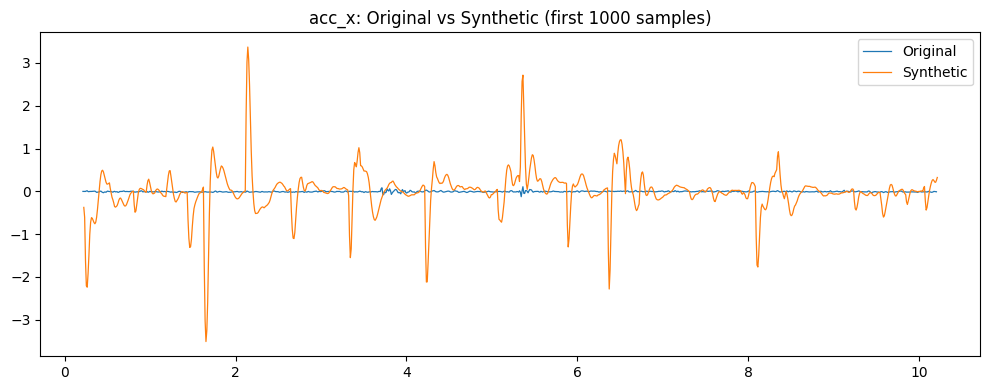

Comparison plot saved to: /content/sample_data/compare_accx.png


,time_seconds,acc_z,acc_y,acc_x,gyro_z,gyro_y,gyro_x,mag_z,mag_y,mag_x,orient_qz,orient_qy,orient_qx,orient_qw,orient_roll,orient_pitch,orient_yaw
0,0.223184,1.999615,-0.334220,-0.375227,-0.549746,-0.106964,-0.521024,-11.162550,-34.739986,0.556926,0.997841,0.032351,-0.011993,0.055888,0.000430,-0.059205,-3.040009
1,0.233184,1.839864,-0.449652,-0.607052,-0.506840,-0.123417,-0.294730,-11.316437,-34.714602,0.634249,0.997634,0.032788,-0.013729,0.058848,-0.036286,-0.053691,-3.072389
2,0.243184,1.907661,-0.733330,-1.626598,-0.478706,-0.154055,-0.062204,-11.766470,-33.507037,0.380907,0.997351,0.034455,-0.014841,0.062323,0.071691,-0.050305,-3.313643
3,0.253184,1.789377,-1.106272,-2.207804,-0.400074,-0.145779,0.149827,-11.818992,-32.915201,0.243903,0.997030,0.036797,-0.015390,0.065887,0.141856,-0.048699,-3.435529
4,0.263184,1.435838,-1.467668,-2.238849,-0.291443,-0.125371,0.312167,-11.708066,-33.201400,0.331928,0.996687,0.039296,-0.015582,0.069481,0.135469,-0.048551,-3.385681


In [ ]:
# ============================================================
# Improved VAR synthetic generator with preprocessing & group-wise VAR
# Colab-ready cell
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import StandardScaler

# -----------------------------
# CONFIGURATION
# -----------------------------
input_path = "/content/drive/MyDrive/CS5103_IITH_PMA_project/Darsh-sitting/merged_sensors_100hz.csv"
output_path = "/content/drive/MyDrive/CS5103_IITH_PMA_project/Darsh-sitting/Correlation/synthetic_sensors_100hz.csv"
plot_path = "/content/sample_data/compare_accx.png"
time_col = "time_seconds"
compare_col = "acc_x"
seed = 42
maxlags = 10
groupwise = False   # True: fit separate VAR per sensor group; False: single VAR on all sensors

np.random.seed(seed)

# -----------------------------
# Helper functions
# -----------------------------
def choose_lag(model, maxlags=10):
    sel = model.select_order(maxlags=maxlags)
    lag = 1
    try:
        aic = sel.aic
        if hasattr(aic, "__len__") and len(aic) > 1:
            lag = int(pd.Series(aic).idxmin())
        else:
            lag = int(aic)
    except Exception:
        try:
            bic = sel.bic
            if hasattr(bic, "__len__") and len(bic) > 1:
                lag = int(pd.Series(bic).idxmin())
            else:
                lag = int(bic) if bic is not None else 1
        except Exception:
            lag = 1
    return max(1, lag)

def fit_simulate_var_on_scaled(scaled_data, n_steps, seed=42, maxlags=10):
    """
    scaled_data: numpy array shape (T, d)
    returns simulated_scaled: numpy array shape (n_steps, d)
    """
    model = VAR(scaled_data)
    lag = choose_lag(model, maxlags=maxlags)
    res = model.fit(lag)
    k_ar = res.k_ar

    # ensure residuals are ndarray
    resid = np.asarray(res.resid)

    rng = np.random.default_rng(seed)
    noise_idx = rng.integers(0, resid.shape[0], size=n_steps)
    noise = resid[noise_idx]

    # initial state: last k_ar rows from scaled_data
    state = scaled_data[-k_ar:].copy()
    sim_preds = []
    for t in range(n_steps):
        pred = res.forecast(state, steps=1)[0]  # scaled prediction
        pred_noisy = pred + noise[t]
        sim_preds.append(pred_noisy)
        # update state
        if k_ar > 1:
            state = np.vstack([state[1:], pred_noisy])
        else:
            state = np.array([pred_noisy])
    sim_array = np.vstack(sim_preds)
    return sim_array, res, lag

def normalize_quaternion_row(df_row, q_cols):
    q = df_row[q_cols].values.astype(float)
    norm = np.linalg.norm(q) + 1e-12
    df_row[q_cols] = q / norm
    return df_row

# -----------------------------
# LOAD & PREPARE DATA
# -----------------------------
df = pd.read_csv(input_path)
if time_col not in df.columns:
    raise ValueError(f"time column '{time_col}' not found in input CSV")

# Keep time aside and operate on numeric sensor columns
time_vals = df[time_col].values
sensor_cols = [c for c in df.columns if c != time_col]
data_df = df[sensor_cols].select_dtypes(include=[np.number]).copy()
if len(data_df.columns) != len(sensor_cols):
    # drop any non-numeric columns silently
    sensor_cols = list(data_df.columns)
print(f"Using {len(sensor_cols)} sensor columns: {sensor_cols[:8]}{'...' if len(sensor_cols)>8 else ''}")
n_steps = len(data_df)

# -----------------------------
# DEFINE GROUPS
# -----------------------------
# adjust these group definitions if your column names differ
groups = {}
if groupwise:
    groups["acc"] = [c for c in sensor_cols if c.startswith("acc_")]
    groups["gyro"] = [c for c in sensor_cols if c.startswith("gyro_")]
    groups["mag"] = [c for c in sensor_cols if c.startswith("mag_")]
    groups["grav"] = [c for c in sensor_cols if c.startswith("grav_")]
    # orientation-related (quaternions + euler)
    orient_cols = [c for c in sensor_cols if c.startswith("orient_")]
    # put orientation in 'orient' group
    groups["orient"] = orient_cols
    # any remaining columns go into 'other'
    used = sum(groups.values(), [])
    other = [c for c in sensor_cols if c not in used]
    if other:
        groups["other"] = other
else:
    groups["all"] = sensor_cols

# Remove empty groups
groups = {k: v for k, v in groups.items() if len(v) > 0}
print("Groups to model:", {k: len(v) for k, v in groups.items()})

# -----------------------------
# Fit VAR per group on scaled data & simulate
# -----------------------------
simulated_parts = {}
group_stats = {}

for gname, cols in groups.items():
    print(f"\nProcessing group '{gname}' with {len(cols)} cols")
    group_df = data_df[cols].astype(float).copy()
    scaler = StandardScaler()
    scaled = scaler.fit_transform(group_df.values)  # shape (T, d)
    sim_scaled, res_obj, lag_used = fit_simulate_var_on_scaled(scaled, n_steps=n_steps, seed=seed, maxlags=maxlags)
    # inverse transform
    sim_inv = scaler.inverse_transform(sim_scaled)
    sim_group_df = pd.DataFrame(sim_inv, columns=cols)
    simulated_parts[gname] = sim_group_df
    group_stats[gname] = {"lag": lag_used, "k_endog": sim_group_df.shape[1]}
    print(f"  fitted lag={lag_used}, produced shape={sim_group_df.shape}")

# -----------------------------
# Reassemble simulated dataframe in original column order
# -----------------------------
sim_df = pd.DataFrame(index=range(n_steps))
for col in sensor_cols:
    # find which group contains the col
    found = False
    for gname, gcols in simulated_parts.items():
        if col in gcols.columns:
            sim_df[col] = gcols[col].values
            found = True
            break
    if not found:
        # fallback: copy original column (shouldn't happen)
        sim_df[col] = data_df[col].values.copy()

# -----------------------------
# Post-processing: quaternion normalization (if present)
# -----------------------------
quat_cols = [c for c in sensor_cols if c in ["orient_qx","orient_qy","orient_qz","orient_qw"]]
if len(quat_cols) == 4:
    print("Normalizing quaternion columns to unit length.")
    # normalize row-wise
    qarr = sim_df[quat_cols].values
    norms = np.linalg.norm(qarr, axis=1) + 1e-12
    sim_df[quat_cols] = qarr / norms[:, None]

# -----------------------------
# Insert time column and save
# -----------------------------
dt = float(np.median(np.diff(time_vals)))
synthetic_times = np.arange(time_vals[0] + dt, time_vals[0] + dt*(n_steps+1), dt)[:n_steps]
sim_df.insert(0, time_col, synthetic_times)

sim_df.to_csv(output_path, index=False)
print(f"\nSaved synthetic CSV -> {output_path}")

# -----------------------------
# Diagnostics: correlation difference & per-group lags
# -----------------------------
orig_corr = data_df.corr()
sim_corr = sim_df[sensor_cols].corr()
avg_corr_diff = (orig_corr - sim_corr).abs().mean().mean()
print(f"\nAverage absolute correlation difference (orig vs synth): {avg_corr_diff:.4f}")
print("Per-group VAR lags:", {g: group_stats[g]["lag"] for g in group_stats})

# -----------------------------
# Quick plot comparison for compare_col
# -----------------------------
if compare_col not in sim_df.columns:
    compare_col = sensor_cols[0]
orig_values = data_df[compare_col].values
plt.figure(figsize=(10,4))
plt.plot(time_vals[:1000], orig_values[:1000], label="Original", linewidth=0.9)
plt.plot(synthetic_times[:1000], sim_df[compare_col].values[:1000], label="Synthetic", linewidth=0.9)
plt.title(f"{compare_col}: Original vs Synthetic (first 1000 samples)")
plt.legend()
plt.tight_layout()
plt.savefig(plot_path)
plt.show()
print(f"Comparison plot saved to: {plot_path}")

# -----------------------------
# Show first rows
# -----------------------------
sim_df.head()
